In [1]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [2]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y, y_pred)
print(conf_matrix)

[[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [4]:
#정확도=예측결과가동일한데이터건수/전체예측데이터건수
#정확도는 직관적으로 모델 예측 성능을 나타내는 평가지표이다.
#하지만 이진 분류의 경우 데이터의 구성에 따라 ML 모델의 성능을 왜곡할 수 있기 때문에 정확도 수치 하나만 가지고 성능을 평가하지 않는다.
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_pred)
print(accuracy)

0.9121265377855887


해석: 전체 예측 데이터 건수의 약 91%가 예측결과가 동일한 데이터 건수이다.

**정밀도의 개념을 설명하고,
정밀도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [6]:
#정밀도 =  TP/(FP+TP)  예측을 Positive로 한 대상 중에 예측과 실제 값이 Positive로 일치한 데이터의 비율을 뜻한다.

from sklearn.metrics import precision_score

precision = precision_score(y, y_pred)
print(precision)

0.900990099009901


해석: 예측을 Positive로 한 대상 중에 예측과 실제 값이 Positive로 일치한 데이터의 비율이 90%이다.

**재현율의 개념을 설명하고, 재현율를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [7]:
#재현율 = $TP/(FN+TP)
#실제 값이 Positive인 대상 중에 예측과 실제 값이 Positive로 일치한 데이터의 비율

from sklearn.metrics import recall_score

recall = recall_score(y,y_pred)
print(recall)

0.8584905660377359


해석: 실제 값이 Positive인 대상 중에 예측과 실제 값이 Positive로 일치한 데이터의 비율이 약 86%이다.

**F1 score의 개념을 설명하고, F1 score를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

$F1 = 2/((1/recall)+(1/precision)) = 2*(precision * recall)/(precision+recall)$

In [8]:
#F1 스코어는 정밀도와 재현율을 결합한 지표이다.
# 정밀도와 재현율이 어느 한 쪽으로 치우치지 않는 수치를 나타낼 때 상대적으로 높은 값을 가진다.
from sklearn.metrics import f1_score

f1 = f1_score(y, y_pred)
print(f1)

0.8792270531400966


해석: 정밀도와 재현율이 균형있게 높다는 것을 알 수 있다.

**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [10]:
from sklearn.preprocessing import Binarizer


In [13]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기
pred_proba = model_lor.predict_proba(X)
print(pred_proba[:5])

# 0(양성)으로 예측할 확률이 0.1보다 크면 y_pred2에 0 (양성)으로 넣습니다.
# 그렇지 않으면 1 (악성)으로 넣습니다.
y_pred2 = (pred_proba[:, 0] > 0.1).astype(int)

print(y_pred2[:5])

[[0.00767198 0.99232802]
 [0.02039507 0.97960493]
 [0.0023654  0.9976346 ]
 [0.61873708 0.38126292]
 [0.00387248 0.99612752]]
[0 0 0 1 0]


**ROC 곡선 시각화**

In [15]:
from sklearn.metrics import roc_curve

In [23]:
import matplotlib.pyplot as plt
import numpy as np


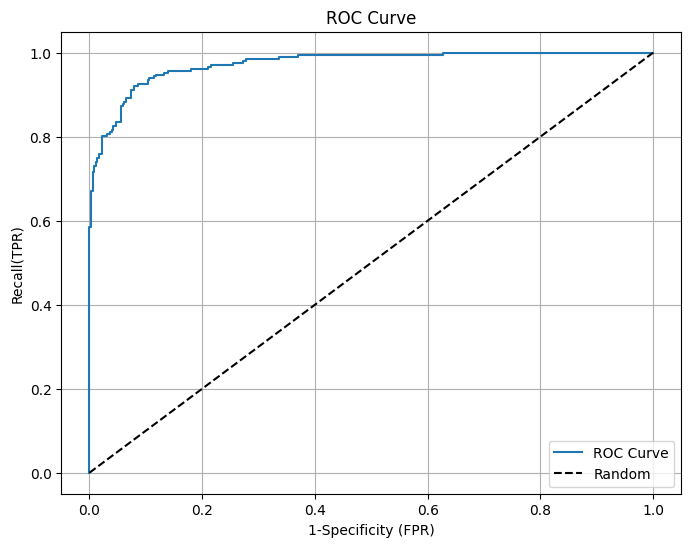

In [30]:
fprs, tprs, thresholds = roc_curve(y, pred_proba[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fprs, tprs, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
#start, end = plt.xlim()
#plt.xticks(np.round(np.arange(start, end, 0.1),2))
#plt.xlim(0,1); plt.ylim(0,1) 을 쓰면 여백을 줄일 수 있지만, 그래프가 잘 안 보임
plt.xlabel('1-Specificity (FPR)')
plt.ylabel('Recall(TPR)')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [28]:
from sklearn.metrics import roc_auc_score

pred_proba_auc = model_lor.predict_proba(X)[:,1]
roc_score = roc_auc_score(y, pred_proba_auc)
print('ROC AUC 값: {0:.4f}'.format(roc_score))

ROC AUC 값: 0.9741


0.97인 것을 보면 모델의 성능이 매우 우수하다는 것을 의미한다. 0.5는 모델이 무작위 예측과 다를 바 없다는 것을 의미하고 1은 양성과 음성을 완벽히 구별한다는 것을 의미한다. 즉 예측력이 매우 우수하다는 것을 알 수 있다.